Célula 1: Importações e Carregamento

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregar dados tratados
df = pd.read_csv('../data/dados_tratados_empreendedorismo_sc.csv')
df['data_abertura'] = pd.to_datetime(df['data_abertura'])

print("Dados carregados com sucesso para análise!")
df.head()

Dados carregados com sucesso para análise!


,id_empresa,nome_fantasia,municipio,segmento,data_abertura,numero_funcionarios,faturamento_anual,status,anos_atividade
0,1,Empresa 1 LTDA,Joinville,Turismo,2023-02-17,103,1884678.63,Ativo,3
1,2,Empresa 2 LTDA,Florianópolis,Comércio,2019-10-11,93,4073357.86,Ativo,6
2,3,Empresa 3 LTDA,Criciúma,Turismo,2021-01-11,15,4738880.46,Ativo,5
3,4,Empresa 4 LTDA,Chapecó,Tecnologia,2012-01-18,107,4930705.27,Ativo,14
4,5,Empresa 5 LTDA,Chapecó,Indústria,2020-07-17,72,3779222.02,Ativo,5


Célula 2: Visão Geral dos Dados

In [3]:
print("📊 Estatísticas Descritivas:")
df.describe()

📊 Estatísticas Descritivas:


,id_empresa,data_abertura,numero_funcionarios,faturamento_anual,anos_atividade
count,480.000000,480,480.000000,4.800000e+02,480.000000
mean,249.820833,2016-12-11 02:56:59.999999744,77.712500,2.469735e+06,8.762500
min,1.000000,2010-01-10 00:00:00,1.000000,7.292851e+04,2.000000
25%,124.750000,2013-04-05 06:00:00,39.000000,1.236292e+06,5.750000
50%,250.500000,2017-03-03 00:00:00,82.000000,2.440016e+06,9.000000
75%,374.250000,2020-03-15 06:00:00,116.000000,3.696707e+06,12.000000
max,500.000000,2023-09-07 00:00:00,148.000000,4.998602e+06,16.000000
std,143.887936,NaN,43.966307,1.407635e+06,3.947179


Célula 3: Gráfico 1 - Empresas por Município

C:\Users\RafaelNR\AppData\Local\Temp\ipykernel_6500\457403948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_municipios.index, y=contagem_municipios.values, palette='viridis')


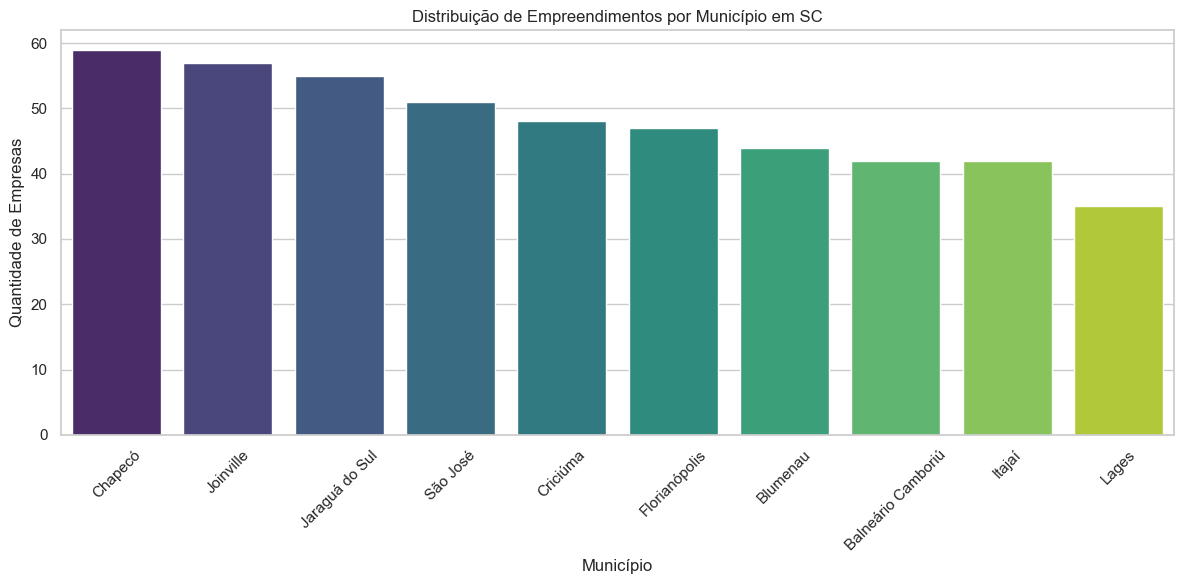

In [4]:
plt.figure(figsize=(12, 6))
contagem_municipios = df['municipio'].value_counts()
sns.barplot(x=contagem_municipios.index, y=contagem_municipios.values, palette='viridis')
plt.title('Distribuição de Empreendimentos por Município em SC')
plt.xlabel('Município')
plt.ylabel('Quantidade de Empresas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Célula 4: Gráfico 2 - Faturamento Médio por Segmento

C:\Users\RafaelNR\AppData\Local\Temp\ipykernel_6500\3073188905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=faturamento_segmento.index, y=faturamento_segmento.values, palette='coolwarm')


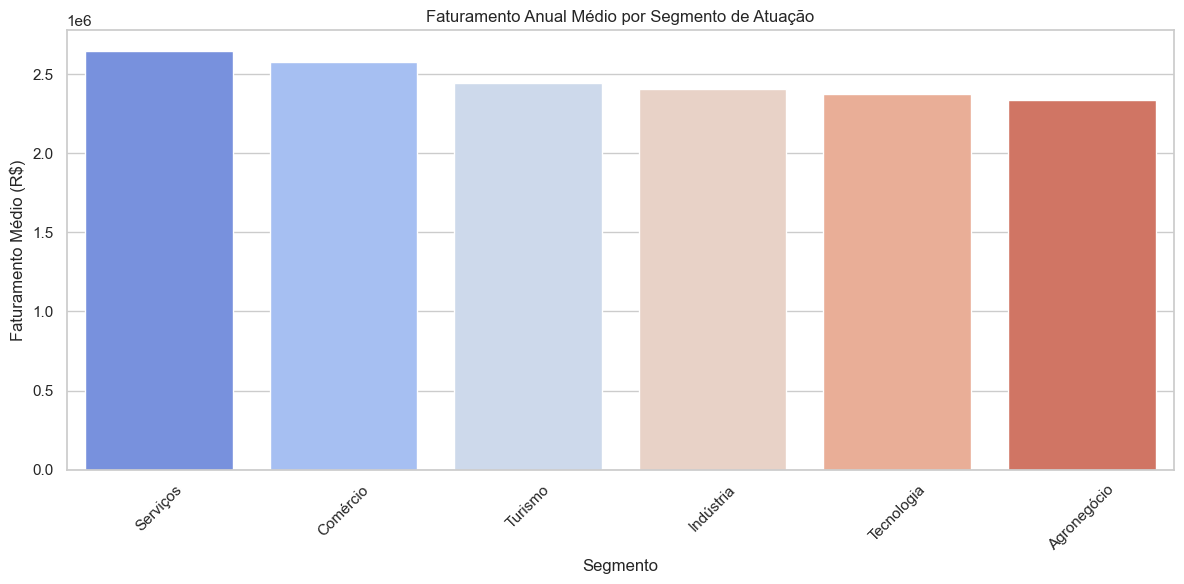

In [5]:
plt.figure(figsize=(12, 6))
faturamento_segmento = df.groupby('segmento')['faturamento_anual'].mean().sort_values(ascending=False)
sns.barplot(x=faturamento_segmento.index, y=faturamento_segmento.values, palette='coolwarm')
plt.title('Faturamento Anual Médio por Segmento de Atuação')
plt.xlabel('Segmento')
plt.ylabel('Faturamento Médio (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Célula 5: Gráfico 3 - Evolução de Aberturas (Anos)

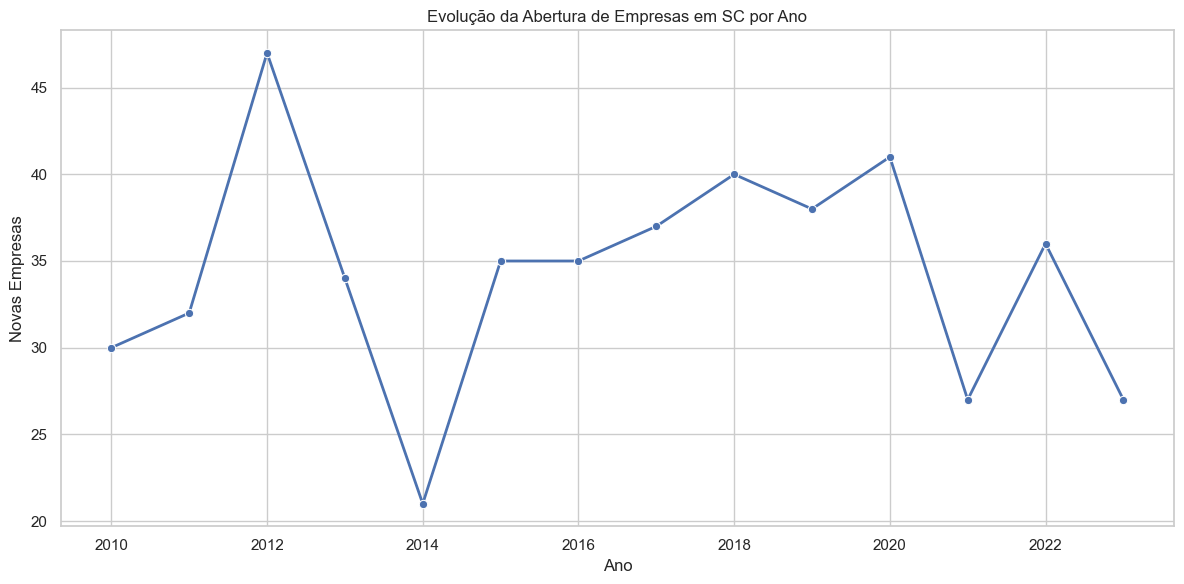

In [6]:
plt.figure(figsize=(12, 6))
df['ano_abertura'] = df['data_abertura'].dt.year
aberturas_por_ano = df['ano_abertura'].value_counts().sort_index()
sns.lineplot(x=aberturas_por_ano.index, y=aberturas_por_ano.values, marker='o', linewidth=2)
plt.title('Evolução da Abertura de Empresas em SC por Ano')
plt.xlabel('Ano')
plt.ylabel('Novas Empresas')
plt.tight_layout()
plt.show()

Célula 6: Conclusão Textual

In [7]:
total_empresas = len(df)
media_funcionarios = df['numero_funcionarios'].mean()
municipio_lider = df['municipio'].mode()[0]

print(f"=== RESUMO DA ANÁLISE ===")
print(f"Total de empresas analisadas: {total_empresas}")
print(f"Média de funcionários por empresa: {media_funcionarios:.1f}")
print(f"Município com maior número de empreendimentos: {municipio_lider}")
print("Conclusão: O setor de tecnologia e comércio apresenta os maiores faturamentos médios, enquanto Florianópolis e Joinville concentram a maior parte do ecossistema empreendedor.")

=== RESUMO DA ANÁLISE ===
Total de empresas analisadas: 480
Média de funcionários por empresa: 77.7
Município com maior número de empreendimentos: Chapecó
Conclusão: O setor de tecnologia e comércio apresenta os maiores faturamentos médios, enquanto Florianópolis e Joinville concentram a maior parte do ecossistema empreendedor.
